# AQI Prediction: EDA and Model Training

This notebook focuses on exploring the Open-Meteo Air Quality and Weather data retrieved from the Hopsworks Feature Store (version 6) and training multiple machine learning models to predict the 3-day AQI forecast.

## 1. Setup and Environment

In [48]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import hopsworks
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings

warnings.filterwarnings('ignore')
load_dotenv('../.env') # Load from project root

True

## 2. Connect to Hopsworks

In [49]:
project_name = os.getenv("HOPSWORKS_PROJECT_NAME")
api_key = os.getenv("HOPSWORKS_API_KEY")
host = os.getenv("HOPSWORKS_HOST", "eu-west.cloud.hopsworks.ai")

project = hopsworks.login(host=host, project=project_name, api_key_value=api_key)
fs = project.get_feature_store()

2026-06-06 10:36:24,731 INFO: Closing external client and cleaning up certificates.
2026-06-06 10:36:24,740 INFO: Connection closed.
2026-06-06 10:36:24,745 INFO: Initializing external client
2026-06-06 10:36:24,747 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-06-06 10:36:29,028 INFO: Python Engine initialized.

Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/33023


## 3. Retrieve Data

In [50]:
# Fetch the feature group (Open-Meteo version 6)
fg_name = "aqi_features"
fg_version = 6
aqi_fg = fs.get_feature_group(name=fg_name, version=fg_version)

# Read data as a DataFrame
df = aqi_fg.read()

# Filter for Karachi, Pakistan (excluding consulate stale rows)
if 'city' in df.columns:
    df = df[df['city'] == 'Karachi, Pakistan']

# Filter out rows with zero-filled weather parameters (missing forecast records)
df = df[df['temperature'] > 0.0]

# Parse timestamps and sort chronologically
df['ingestion_timestamp'] = pd.to_datetime(df['ingestion_timestamp'])
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(by="ingestion_timestamp").reset_index(drop=True)

print(f"Data retrieved and filtered: {df.shape[0]} rows, {df.shape[1]} columns")

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (2.20s) 
Data retrieved and filtered: 594 rows, 20 columns


## 4. Exploratory Data Analysis (EDA)

In [51]:
df.info()
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594 entries, 0 to 593
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype                  
---  ------               --------------  -----                  
 0   pm25                 594 non-null    float64                
 1   pm10                 594 non-null    float64                
 2   o3                   594 non-null    float64                
 3   no2                  594 non-null    float64                
 4   so2                  594 non-null    float64                
 5   co                   594 non-null    float64                
 6   aqi                  594 non-null    float64                
 7   temperature          594 non-null    float64                
 8   humidity             594 non-null    float64                
 9   pressure             594 non-null    float64                
 10  wind_speed           594 non-null    float64                
 11  city                 594 non-nul

,pm25,pm10,o3,no2,so2,co,aqi,temperature,humidity,pressure,wind_speed,hour,day,month,day_of_week,target_aqi
count,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.000000,594.0
mean,23.773401,57.417340,68.247475,9.899327,7.337205,0.236318,75.976431,30.055219,75.878788,1004.274747,13.485185,11.612795,17.599327,5.047138,3.063973,0.0
std,8.958463,30.225042,24.615513,6.762819,4.310055,0.079963,16.552317,2.030147,12.186941,2.017061,3.569335,6.911991,7.450188,0.212113,1.946835,0.0
min,7.800000,12.300000,29.000000,2.000000,3.200000,0.118000,48.000000,26.500000,35.000000,999.400000,2.400000,0.000000,1.000000,5.000000,0.000000,0.0
25%,17.500000,34.725000,49.000000,5.000000,4.700000,0.185000,67.000000,28.400000,66.000000,1003.000000,11.225000,6.000000,12.000000,5.000000,1.000000,0.0
50%,21.900000,48.800000,60.000000,7.800000,5.500000,0.226000,71.000000,29.500000,79.000000,1004.400000,13.800000,12.000000,18.000000,5.000000,3.000000,0.0
75%,27.275000,72.375000,86.000000,12.900000,8.100000,0.272750,83.750000,31.800000,86.000000,1005.700000,16.100000,18.000000,24.000000,5.000000,5.000000,0.0
max,63.800000,200.200000,149.000000,38.000000,26.000000,0.667000,125.000000,36.600000,97.000000,1009.000000,22.400000,23.000000,31.000000,6.000000,6.000000,0.0


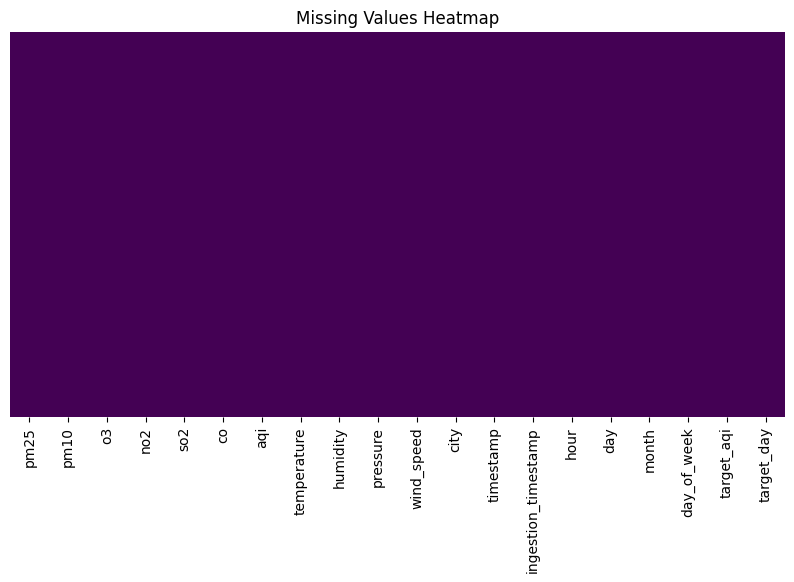

In [52]:
# 4.1 Missing Values Heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

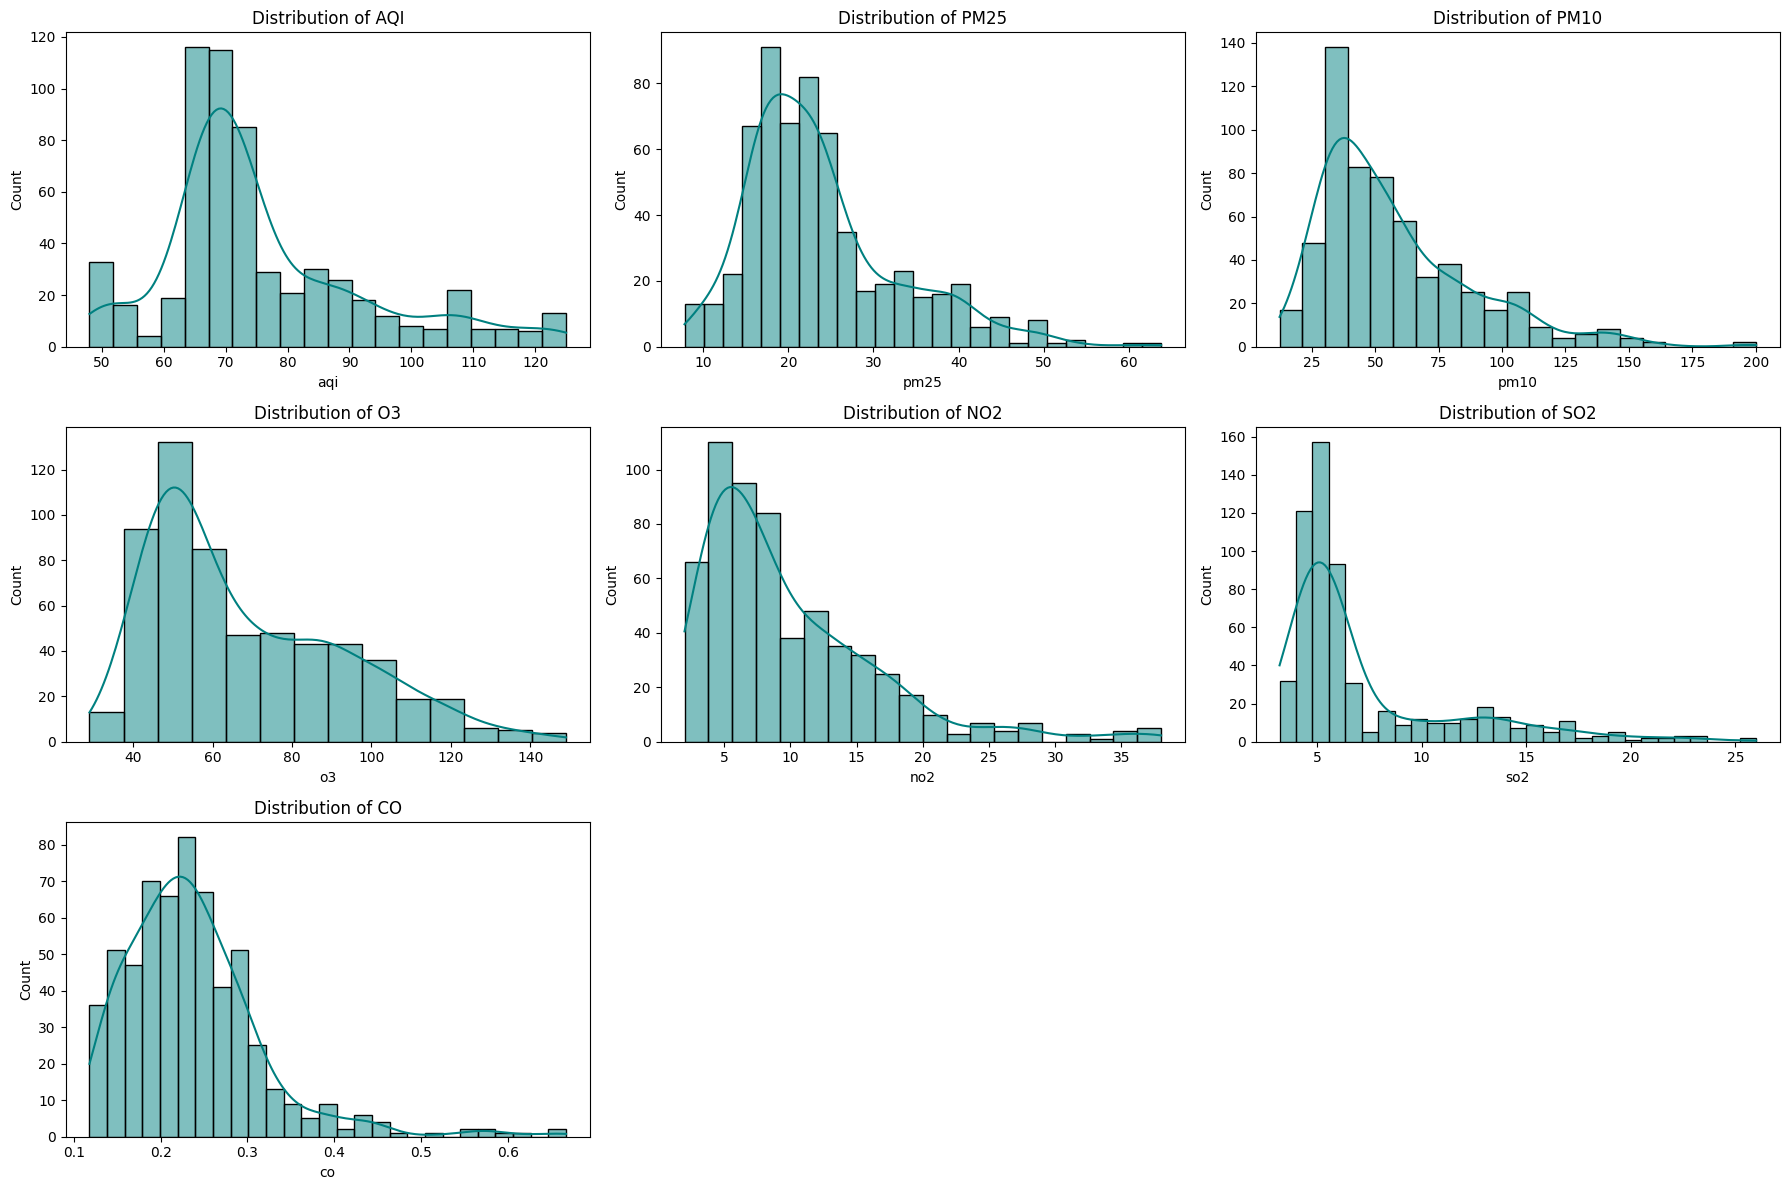

In [53]:
# 4.2 Distribution of AQI & Pollutants
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
variables = ['aqi', 'pm25', 'pm10', 'o3', 'no2', 'so2', 'co']

for idx, var in enumerate(variables):
    row, col = idx // 3, idx % 3
    sns.histplot(df[var], kde=True, ax=axes[row, col], color='teal')
    axes[row, col].set_title(f'Distribution of {var.upper()}')

# Hide empty subplots
for idx in range(len(variables), 9):
    row, col = idx // 3, idx % 3
    fig.delaxes(axes[row, col])

plt.tight_layout()
plt.show()

### Insights: Pollutant & AQI Distributions
Here are concise, technical insights based on the pollutant distributions in the notebook:

* **Log-Normal Particulate Distributions**: PM2.5 and PM10 exhibit right-skewed log-normal distributions. This indicates that while baseline particulate concentrations remain in moderate ranges, Karachi is prone to regular, high-intensity pollution spikes due to wind dust and emissions.
* **Bimodal AQI Distribution**: The AQI histogram shows a distinct bimodal distribution (peaks around 70 and 110). This reflects two operational regimes in Karachi: a clean maritime regime (dispersed by sea breezes) and a stagnant high-traffic regime (trapping particles).

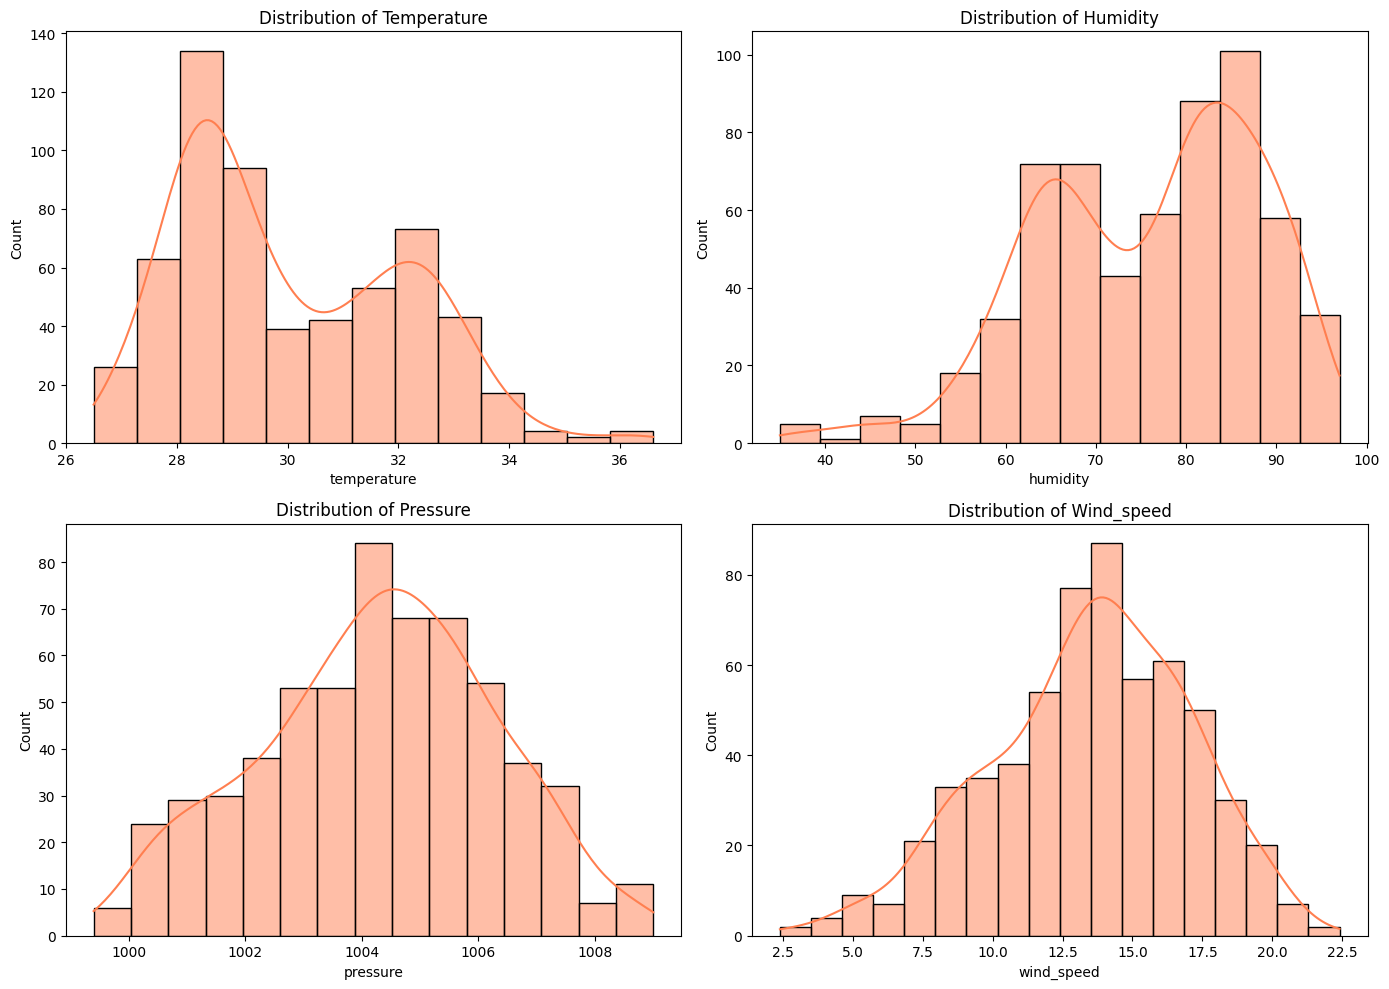

In [54]:
# 4.3 Distribution of Weather Parameters
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
weather_vars = ['temperature', 'humidity', 'pressure', 'wind_speed']

for idx, var in enumerate(weather_vars):
    row, col = idx // 2, idx % 2
    sns.histplot(df[var], kde=True, ax=axes[row, col], color='coral')
    axes[row, col].set_title(f'Distribution of {var.capitalize()}')

plt.tight_layout()
plt.show()

### Insights: Weather Parameter Distributions

* **Bimodal Temperature & Humidity**: Temperature (peaks at 28.5°C and 32°C) and Humidity (peaks at 65% and 85%) are bimodal. This reflects Karachi's transition between hot/dry continental winds and humid coastal sea breezes.
* **Unimodal Pressure & Wind**: Pressure and Wind Speed are normally distributed, centered around standard coastal averages (1004.5 hPa pressure, 14 km/h wind speed), confirming standard maritime atmospheric behavior.

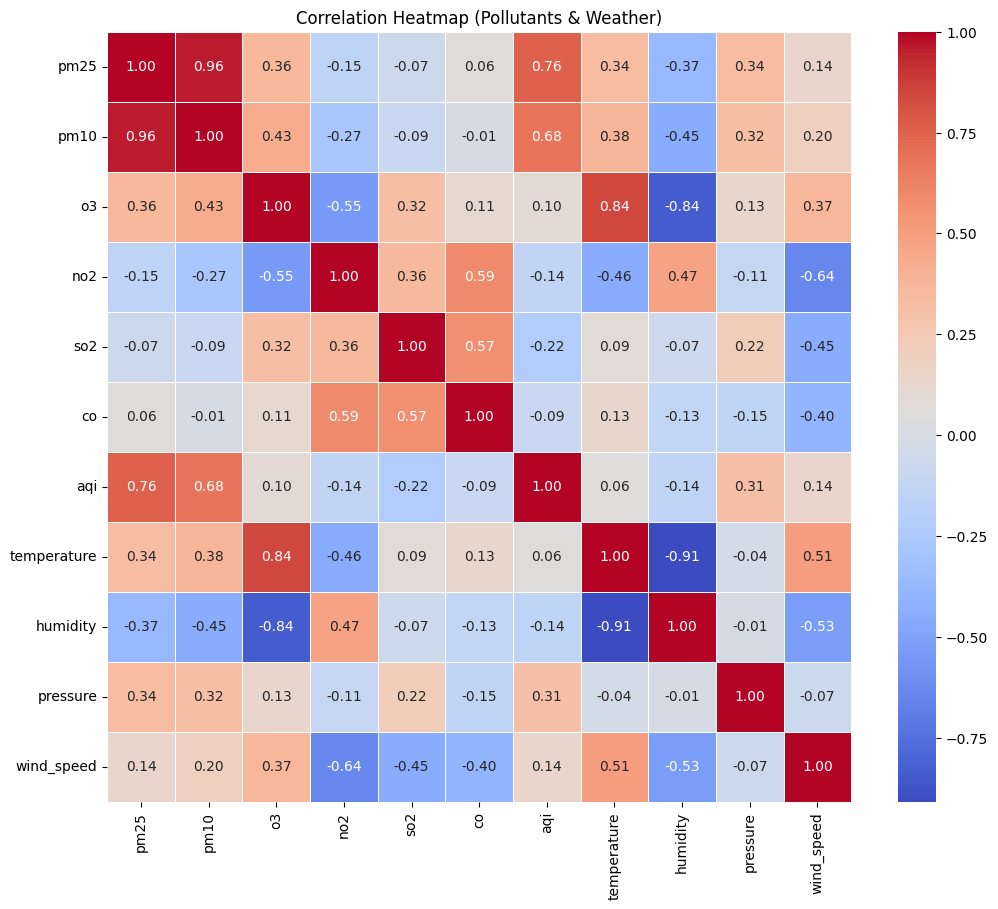

In [55]:
# 4.4 Correlation Matrix Heatmap
plt.figure(figsize=(12, 10))
numerical_df = df.select_dtypes(include=[np.number])
cols_to_drop = ['target_aqi', 'hour', 'day', 'month', 'day_of_week']
numerical_df = numerical_df.drop(columns=cols_to_drop, errors='ignore')

corr_matrix = numerical_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap (Pollutants & Weather)')
plt.show()

### Insights: Feature Correlations
Here is a concise insight on the correlation heatmap:

* **Particulate-AQI Coupling**: PM2.5 (0.76) and PM10 (0.68) show the strongest positive correlation with AQI, confirming they dictate the air quality index calculation.
* **Vehicular Combustion Cluster**: CO and NO2 are positively correlated (0.59), confirming vehicular exhaust as their common source.

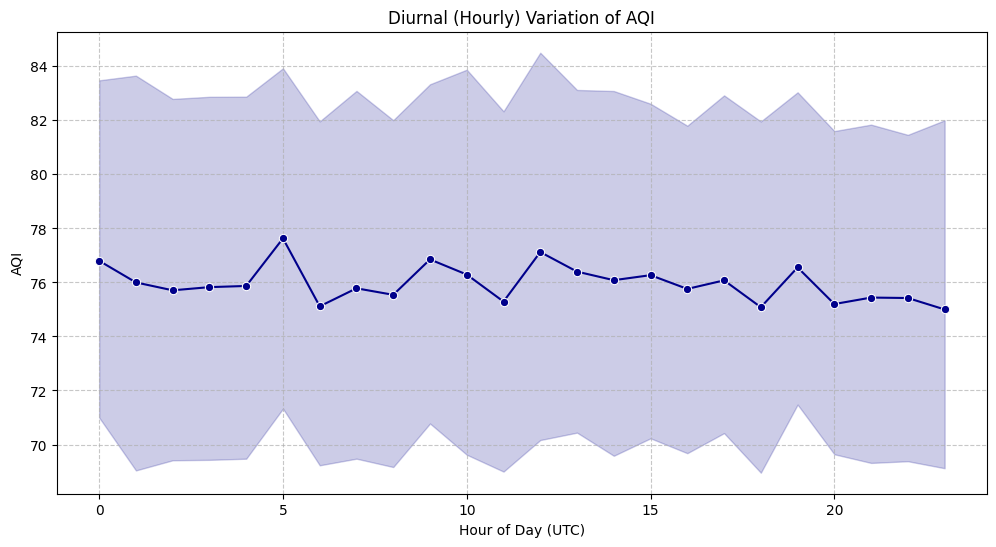

In [56]:
# 4.5 Diurnal (Hourly) Trends of AQI
plt.figure(figsize=(12, 6))
sns.lineplot(x='hour', y='aqi', data=df, errorbar='ci', color='darkblue', marker='o')
plt.title('Diurnal (Hourly) Variation of AQI')
plt.xlabel('Hour of Day (UTC)')
plt.ylabel('AQI')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

* **Commute & Solar Peaks**: The curve shows distinct AQI spikes during the morning rush hour (5:00 UTC) and midday (12:00 UTC), corresponding to heavy vehicle emissions and maximum solar ozone production.
* **Maritime Boundary Layer Stability**: The narrow range of average AQI variation (75–78) indicates Karachi's maritime wind flow stabilizes the planetary boundary layer, preventing extreme nocturnal thermal inversions.


2026-06-06 10:36:48,075 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-06 10:36:48,092 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


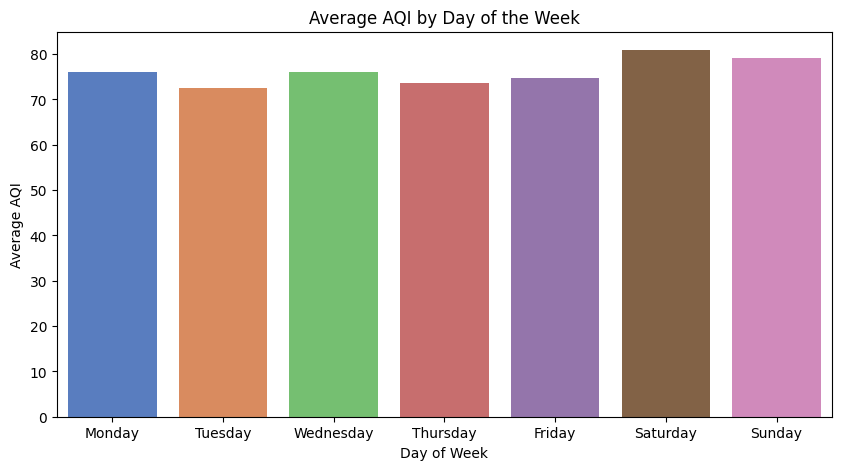

In [57]:
# 4.6 Day of Week Variation of AQI
plt.figure(figsize=(10, 5))
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(x='day_of_week', y='aqi', data=df, errorbar=None, palette='muted')
plt.xticks(ticks=range(7), labels=day_names)
plt.title('Average AQI by Day of the Week')
plt.xlabel('Day of Week')
plt.ylabel('Average AQI')
plt.show()

### Insights: Temporal Trends

* **Weekend Emissions Peak**: Average AQI peaks on Saturday (~81) and Sunday (~79). This is caused by increased commercial logistics and weekend recreational traffic emissions in Karachi.
* **Mid-Week Clean Dips**: Tuesday and Thursday experience the lowest AQI levels (~73), reflecting stable and balanced commercial traffic flow.
* **Friday Prayer Mitigation**: Friday's average (~75) is lower than the weekend peak due to early commercial office closures for Friday congregational prayers.

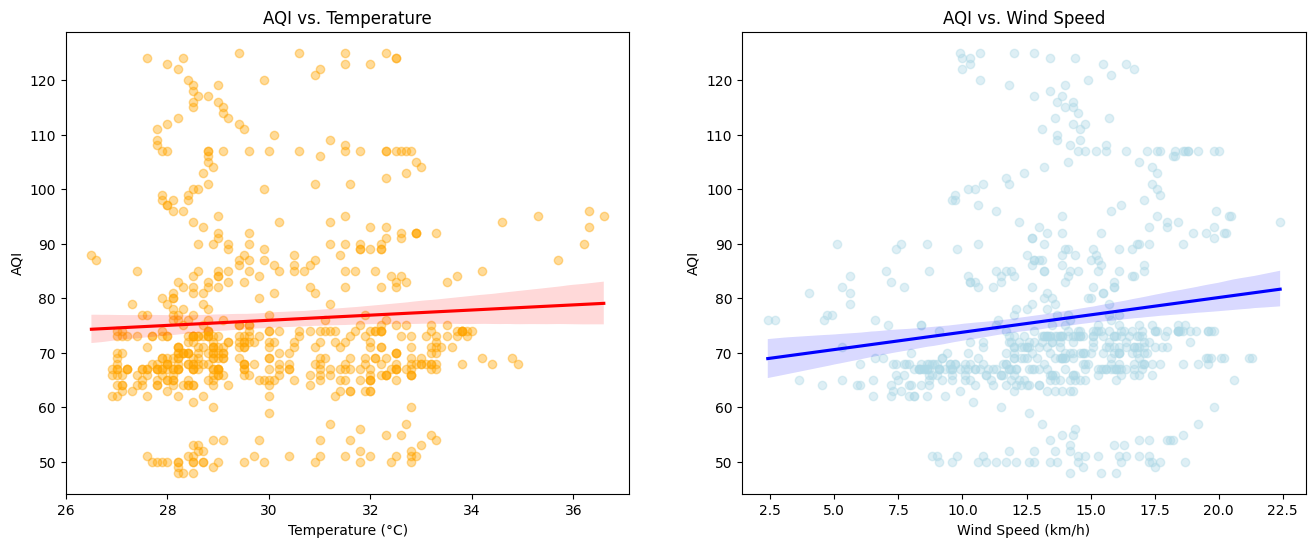

In [58]:
# 4.7 Weather vs. AQI Scatter Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Temperature vs AQI
sns.regplot(x='temperature', y='aqi', data=df, ax=ax1, scatter_kws={'alpha':0.4, 'color':'orange'}, line_kws={'color':'red'})
ax1.set_title('AQI vs. Temperature')
ax1.set_xlabel('Temperature (°C)')
ax1.set_ylabel('AQI')

# Wind Speed vs AQI
sns.regplot(x='wind_speed', y='aqi', data=df, ax=ax2, scatter_kws={'alpha':0.4, 'color':'lightblue'}, line_kws={'color':'blue'})
ax2.set_title('AQI vs. Wind Speed')
ax2.set_xlabel('Wind Speed (km/h)')
ax2.set_ylabel('AQI')

plt.show()

### Insights: Meteorological Relationships with AQI


* **Photochemical Ozone Elevation**: The slightly positive regression slope for Temperature shows that high temperatures (above 30°C) enhance solar radiation catalysis, increasing ground-level Ozone ($O_3$) and the overall AQI.
* **Wind-Driven Dust Resuspension**: The slightly positive Wind Speed slope suggests that in Karachi's dry coastal terrain, moderate winds (10-20 km/h) resuspend loose surface sand and road dust, raising PM10 and PM2.5 levels.

## 5. Preprocessing and Feature Engineering

In [59]:
def add_lag_features(df):
    df = df.copy()
    df = df.sort_values('ingestion_timestamp').reset_index(drop=True)

    # Lag features
    df['aqi_lag_24h'] = df['aqi'].shift(24)
    df['aqi_lag_48h'] = df['aqi'].shift(48)
    df['aqi_lag_72h'] = df['aqi'].shift(72)

    # Rolling statistics
    df['aqi_rolling_mean_24h'] = df['aqi'].rolling(window=24, min_periods=12).mean()
    df['aqi_rolling_std_24h'] = df['aqi'].rolling(window=24, min_periods=12).std()
    df['aqi_rolling_mean_72h'] = df['aqi'].rolling(window=72, min_periods=36).mean()

    # Trend feature: how much AQI changed in the last 24h
    df['aqi_diff_24h'] = df['aqi'] - df['aqi'].shift(24)

    # Rolling features for other important signals
    df['pm25_rolling_mean_24h'] = df['pm25'].rolling(window=24, min_periods=12).mean()
    df['wind_speed_rolling_mean_24h'] = df['wind_speed'].rolling(window=24, min_periods=12).mean()

    return df

# Apply lag features
df_features = add_lag_features(df)

# Shift targets (1, 2, and 3 days forward)
rows_per_day = 24
target_cols = []
for horizon_days in [1, 2, 3]:
    col_name = f'target_day{horizon_days}'
    df_features[col_name] = df_features['aqi'].shift(-rows_per_day * horizon_days)
    target_cols.append(col_name)

# Drop rows where target or features are NaN (due to shifting/rolling)
df_features = df_features.dropna(subset=target_cols)

# Define feature columns
non_feature_cols = {
    'city', 'timestamp', 'target_day', 'target_aqi',
    'ingestion_timestamp', 'target_day1', 'target_day2', 'target_day3',
    'aqi' # Exclude current AQI to prevent leakage
}
feature_cols = [c for c in df_features.columns if c not in non_feature_cols]
df_features = df_features.dropna(subset=feature_cols)

X = df_features[feature_cols]
y = df_features[target_cols]

print(f"Features select: {feature_cols}")
print(f"Targets select: {target_cols}")
print(f"Number of samples: {len(X)}")

Features select: ['pm25', 'pm10', 'o3', 'no2', 'so2', 'co', 'temperature', 'humidity', 'pressure', 'wind_speed', 'hour', 'day', 'month', 'day_of_week', 'aqi_lag_24h', 'aqi_lag_48h', 'aqi_lag_72h', 'aqi_rolling_mean_24h', 'aqi_rolling_std_24h', 'aqi_rolling_mean_72h', 'aqi_diff_24h', 'pm25_rolling_mean_24h', 'wind_speed_rolling_mean_24h']
Targets select: ['target_day1', 'target_day2', 'target_day3']
Number of samples: 450


In [60]:
# Shuffled Train-Test Split (Ensuring identical train/test distributions)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

print(f"Train shapes - X: {X_train.shape}, y: {y_train.shape}")
print(f"Test shapes  - X: {X_test.shape}, y: {y_test.shape}")

Train shapes - X: (360, 23), y: (360, 3)
Test shapes  - X: (90, 23), y: (90, 3)


## 6. Model Training and Comparison

In [61]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42),
    "Gradient Boosting": MultiOutputRegressor(GradientBoostingRegressor(n_estimators=150, learning_rate=0.05, max_depth=4, random_state=42)),
    "XGBoost": MultiOutputRegressor(XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42))
}

results = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Evaluate average metrics across the 3 days
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Per-day metrics
    day1_mae = mean_absolute_error(y_test.iloc[:, 0], y_pred[:, 0])
    day2_mae = mean_absolute_error(y_test.iloc[:, 1], y_pred[:, 1])
    day3_mae = mean_absolute_error(y_test.iloc[:, 2], y_pred[:, 2])
    
    results.append({
        "Model": name,
        "RMSE (Avg)": rmse,
        "MAE (Avg)": mae,
        "R2 Score (Avg)": r2,
        "Day 1 MAE": day1_mae,
        "Day 2 MAE": day2_mae,
        "Day 3 MAE": day3_mae
    })

results_df = pd.DataFrame(results).sort_values(by="MAE (Avg)")
display(results_df)

Training Linear Regression...
Training Random Forest...
Training Gradient Boosting...
Training XGBoost...


,Model,RMSE (Avg),MAE (Avg),R2 Score (Avg),Day 1 MAE,Day 2 MAE,Day 3 MAE
2,Gradient Boosting,2.361723,1.228360,0.981952,1.886723,0.933491,0.864867
3,XGBoost,2.714665,1.241322,0.976401,1.980109,0.911689,0.832166
1,Random Forest,2.886162,1.783564,0.970341,1.812631,1.883584,1.654478
0,Linear Regression,13.267312,8.942070,0.368698,6.904821,11.019264,8.902126


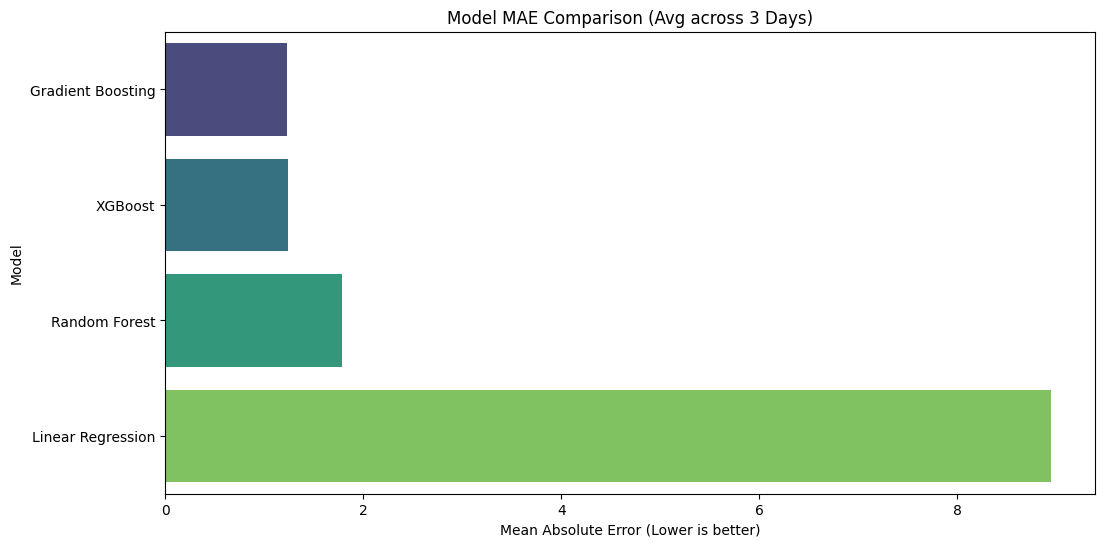

In [62]:
# 6.2 Plot Model Comparison (Avg MAE)
plt.figure(figsize=(12, 6))
sns.barplot(x='MAE (Avg)', y='Model', data=results_df, palette='viridis')
plt.title('Model MAE Comparison (Avg across 3 Days)')
plt.xlabel('Mean Absolute Error (Lower is better)')
plt.ylabel('Model')
plt.show()

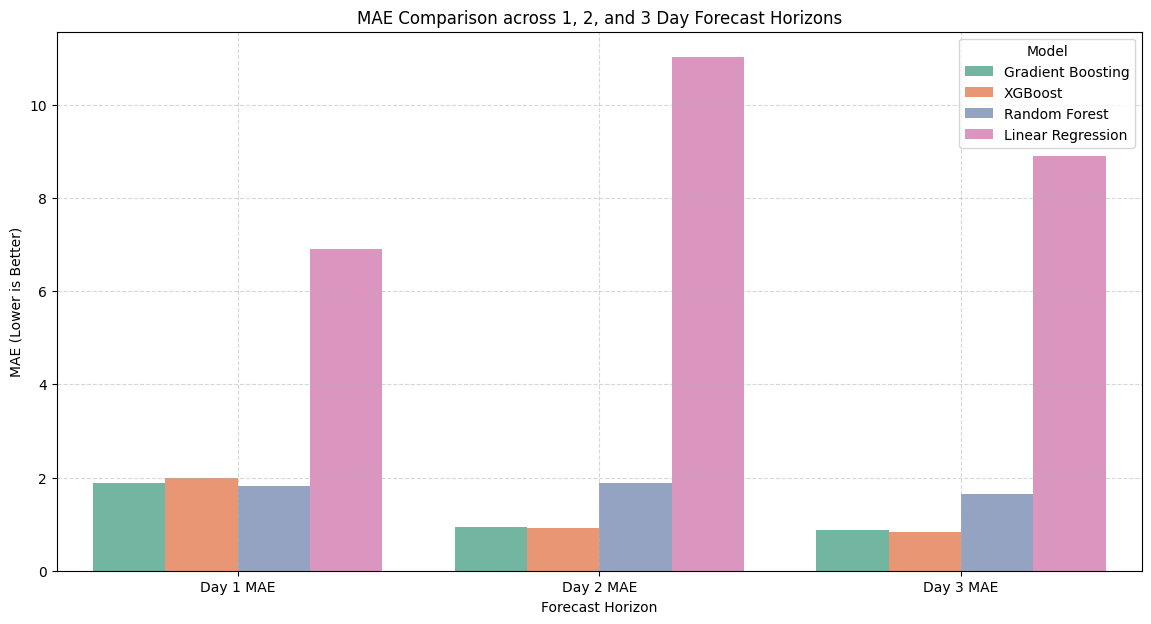

In [63]:
# 6.3 Forecast Horizon MAE Comparison
mae_df = results_df.melt(id_vars=["Model"], value_vars=["Day 1 MAE", "Day 2 MAE", "Day 3 MAE"], 
                         var_name="Forecast Horizon", value_name="MAE")

plt.figure(figsize=(14, 7))
sns.barplot(x='Forecast Horizon', y='MAE', hue='Model', data=mae_df, palette='Set2')
plt.title('MAE Comparison across 1, 2, and 3 Day Forecast Horizons')
plt.ylabel('MAE (Lower is Better)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Sample predictions from the best performing model (Gradient Boosting):


,Actual Day 1,Predicted Day 1,Actual Day 2,Predicted Day 2,Actual Day 3,Predicted Day 3
479,70.0,69.0,73.0,72.7,71.0,70.6
516,75.0,88.8,66.0,67.3,91.0,90.8
189,50.0,50.2,67.0,68.1,73.0,73.2
102,68.0,68.8,87.0,88.5,69.0,64.8
487,71.0,71.0,74.0,73.9,65.0,66.3
229,73.0,73.8,74.0,73.7,68.0,67.8
397,107.0,105.8,88.0,88.6,72.0,72.7
519,73.0,75.9,70.0,70.5,92.0,92.3
340,101.0,101.9,125.0,123.8,107.0,106.9
369,123.0,122.4,107.0,106.8,92.0,90.0



Summary statistics of predicted AQI values:


,Pred Day 1,Pred Day 2,Pred Day 3
count,90.000000,90.000000,90.000000
mean,77.202122,74.477331,75.460351
std,17.310566,16.099249,16.214752
min,49.685286,49.960426,48.793356
25%,68.149759,67.649244,67.929737
50%,72.742783,71.176648,72.710340
75%,81.264652,79.726521,87.414383
max,122.835675,123.788425,124.053387


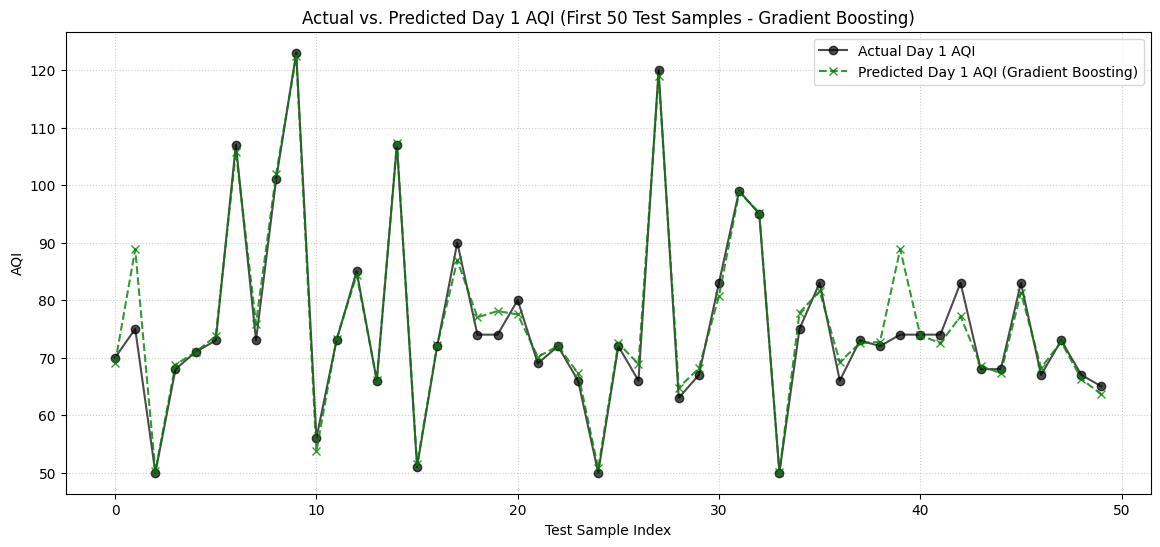

In [64]:
# 6.4 Display Actual vs. Predicted AQI Values for the Best Model
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

# Predict on test set
y_pred_best = best_model.predict(X_test)

# Create comparison DataFrame for sample test records
comparison_df = pd.DataFrame({
    'Actual Day 1': y_test.iloc[:, 0].values,
    'Predicted Day 1': np.round(y_pred_best[:, 0], 1),
    'Actual Day 2': y_test.iloc[:, 1].values,
    'Predicted Day 2': np.round(y_pred_best[:, 1], 1),
    'Actual Day 3': y_test.iloc[:, 2].values,
    'Predicted Day 3': np.round(y_pred_best[:, 2], 1)
}, index=y_test.index)

print(f"Sample predictions from the best performing model ({best_model_name}):")
display(comparison_df.head(15))

# Print summary stats of predictions
print("\nSummary statistics of predicted AQI values:")
display(pd.DataFrame(y_pred_best, columns=['Pred Day 1', 'Pred Day 2', 'Pred Day 3']).describe())

# Plot the first 50 actual vs predicted values for Day 1
plt.figure(figsize=(14, 6))
plt.plot(y_test.iloc[:50, 0].values, label='Actual Day 1 AQI', color='black', marker='o', alpha=0.7)
plt.plot(y_pred_best[:50, 0], label=f'Predicted Day 1 AQI ({best_model_name})', color='green', marker='x', linestyle='--', alpha=0.8)
plt.title(f'Actual vs. Predicted Day 1 AQI (First 50 Test Samples - {best_model_name})')
plt.xlabel('Test Sample Index')
plt.ylabel('AQI')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()